In [267]:
pip install matplotlib numpy scipy jupyter

Note: you may need to restart the kernel to use updated packages.


In [268]:
import numpy as np

In [269]:
# Part 1a: Creating a packet represented by a vector of random bits
PACKET_LENGTH = 4160
packet = np.random.randint(0, 2, PACKET_LENGTH)
print ("************ Original Packet ****************")
print(f"Packet: {packet}")
print(f"Size of packet: {len(packet)} bits")

# Converting digital bits into QPSK symbols
def bits_to_qpsk_symbols(bits: np.ndarray) -> np.ndarray:
    # Reshape bits into pairs
    bit_pairs = bits.reshape(-1, 2)
    symbol_map = {
        (0, 0): 1 + 0j,
        (0, 1): 0 + 1j,
        (1, 0): -1 + 0j,
        (1, 1): 0 - 1j
    }
    symbols = np.array([symbol_map[tuple(pair)] for pair in bit_pairs])
    return symbols
print ("************ QPSK Conversion ****************")
qpsk_symbols = bits_to_qpsk_symbols(packet)
print(f"QPSK Symbols: {qpsk_symbols}")
print(f"Number of QPSK Symbols: {len(qpsk_symbols)}")

# Converting QPSK symbols into OFDM symbols
print ("************ OFDM Conversion ****************")
N_FFT = 64
pilot_sc = np.array([-21, -7, 7, 21])
temp_sc = np.r_[np.arange(-26, 0), np.arange(1, 27)]
data_sc = np.setdiff1d(temp_sc, pilot_sc)

pilot_bins = pilot_sc % N_FFT # -> indices [43, 57, 7, 21]
data_bins  = data_sc  % N_FFT
null_bins  = np.setdiff1d(np.arange(N_FFT), np.r_[pilot_bins, data_bins])

def pack_ofdm_fd(qpsk: np.ndarray) -> np.ndarray:
    BLOCK = 48  # Number of data subcarriers per OFDM symbol
    pad = (-len(qpsk)) % BLOCK                
    if pad:
        qpsk = np.pad(qpsk, (0, pad), constant_values=0)
    n_syms = (len(qpsk)) // BLOCK               

    data_blocks = qpsk.reshape(n_syms, BLOCK)   

    X = np.zeros((n_syms, N_FFT), dtype=complex) 
    X[:, pilot_bins] = 1+0j                      # Fixing pilots to 1+0j
    X[:, data_bins]  = data_blocks                    
    return X, n_syms

ofdm_symbols, n_syms = pack_ofdm_fd(qpsk_symbols)
print(f"OFDM Symbols: {ofdm_symbols}")
print(f"Built {n_syms} OFDM symbols (64 bins each);")


************ Original Packet ****************
Packet: [1 1 1 ... 1 1 0]
Size of packet: 4160 bits
************ QPSK Conversion ****************
QPSK Symbols: [ 0.-1.j  0.-1.j -1.+0.j ...  1.+0.j  0.-1.j -1.+0.j]
Number of QPSK Symbols: 2080
************ OFDM Conversion ****************
OFDM Symbols: [[ 0.+0.j  0.-1.j  0.-1.j ...  0.-1.j  0.-1.j  0.+1.j]
 [ 0.+0.j  0.+1.j  0.+1.j ...  1.+0.j -1.+0.j  1.+0.j]
 [ 0.+0.j  0.-1.j  0.+1.j ...  0.-1.j  1.+0.j  0.+1.j]
 ...
 [ 0.+0.j -1.+0.j  0.-1.j ...  1.+0.j  1.+0.j  0.-1.j]
 [ 0.+0.j  0.+1.j  0.+1.j ...  0.-1.j  0.-1.j  0.+1.j]
 [ 0.+0.j  0.+0.j  0.+0.j ...  0.+0.j  0.+0.j  0.+0.j]]
Built 44 OFDM symbols (64 bins each);


In [270]:
# Part 1b: Modulate each OFDM symbol using 64-point IFFT, and add a 16-sample cyclic prefix to it
def ofdm_modulate(ofdm_symbols: np.ndarray) -> np.ndarray:
    CP_LEN = 16  # Length of cyclic prefix
    
    # Performing 64-point IFFT
    time_domain_symbols = np.fft.ifft(ofdm_symbols, n=N_FFT, axis=1)

    # Adding cyclic prefix
    cyclic_prefix = time_domain_symbols[:, -CP_LEN:]
    time_domain_with_cp = np.hstack((cyclic_prefix, time_domain_symbols))
    return time_domain_with_cp.reshape(-1)

tx_signal = ofdm_modulate(ofdm_symbols)
print ("************ OFDM Modulation ****************") 
print(f"Transmitted Signal: {tx_signal}")

************ OFDM Modulation ****************
Transmitted Signal: [ 0.046875  +0.140625j   -0.0815595 +0.02838225j -0.33134003-0.09059551j
 ...  0.0367652 +0.05389596j  0.01998263+0.00185554j
  0.04659681-0.02324463j]


In [ ]:
# Part 1c: Adding STF and LTF preambles to each data packet

# From discussion definitions...
stf_pattern = np.sqrt(13/6) * np.array([
    0, 0, 1+1j, 0, 0, 0, -1-1j, 0, 0, 0, 1+1j, 0, 0, 0, -1-1j, 0, 0, 0, -1-1j, 0, 0, 0, 1+1j, 0, 0, 0, 0,
    0, 0, 0, -1-1j, 0, 0, 0, -1-1j, 0, 0, 0, 1+1j, 0, 0, 0, 1+1j, 0, 0, 0, 1+1j, 0, 0, 0, 1+1j, 0, 0, 
])
ltf_pattern = np.array([
    1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 0, 
    1, -1, -1, 1, 1, -1, 1, -1, 1,-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1
])

sc53 = np.r_[np.arange(-26, 0), [0], np.arange(1, 27)]

# STF, to time domain
stf_fd = np.zeros(N_FFT, dtype=complex)
stf_fd[sc53 % N_FFT] = stf_pattern.astype(complex)
stf_td = np.fft.ifft(stf_fd, n=N_FFT)
stf_short = stf_td[:16]
stf_time  = np.tile(stf_short, 10)

# LTF, to time domain
ltf_fd = np.zeros(N_FFT, dtype=complex)
ltf_fd[sc53 % N_FFT] = ltf_pattern.astype(complex)
ltf_td = np.fft.ifft(ltf_fd, n=N_FFT)
ltf_cp   = ltf_td[-32:]
ltf_time = np.concatenate([ltf_cp, ltf_td, ltf_td])

tx_packet = np.concatenate([stf_time, ltf_time, tx_signal])

print(f"STF len: {len(stf_time)}  | LTF len: {len(ltf_time)}  | Data len: {len(tx_signal)}")
print(f"Total packet length: {len(tx_packet)} samples")

STF len: 160  | LTF len: 160  | Data len: 3520
Total packet length: 3840 samples


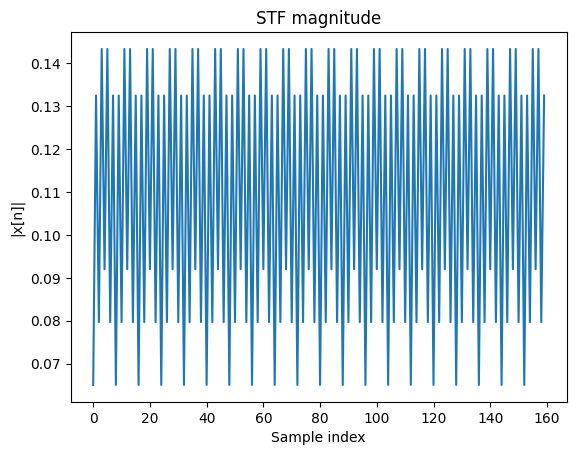

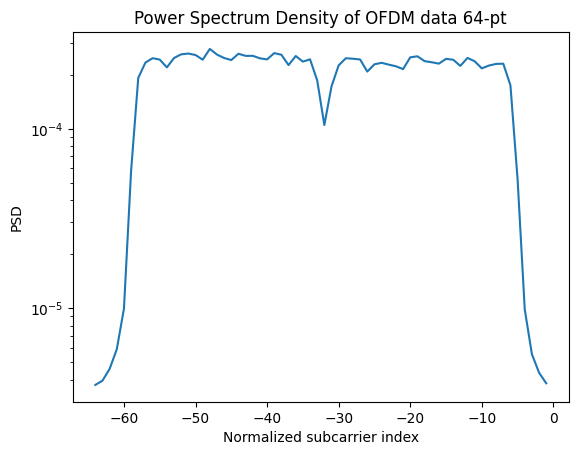

In [272]:
# Part 1d Plot the magnitude of samples in resulting STF, plot power spectrum density of OFDM data symbols using 64-point FFT

import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.signal.windows import hann as hanning

# Plotting magnitude of samples in STF
plt.figure()
plt.plot(np.abs(stf_time))
plt.title("STF magnitude")
plt.xlabel("Sample index")
plt.ylabel("|x[n]|")

# Power Spectrum density of OFDM data symbols
win = hanning(N_FFT, sym=False)
f, Pxx = welch(
    tx_signal,
    fs=N_FFT,
    window=win,
    nperseg=N_FFT,
    noverlap=N_FFT // 2,
    detrend=False,
    return_onesided=False,
    scaling="density",
)
f_shift = np.fft.fftshift(f) - N_FFT / 2.0
Pxx_shift = np.fft.fftshift(Pxx)

plt.figure()
plt.semilogy(f_shift, Pxx_shift)
plt.title("Power Spectrum Density of OFDM data 64-pt")
plt.xlabel("Normalized subcarrier index")
plt.ylabel("PSD")

plt.show()

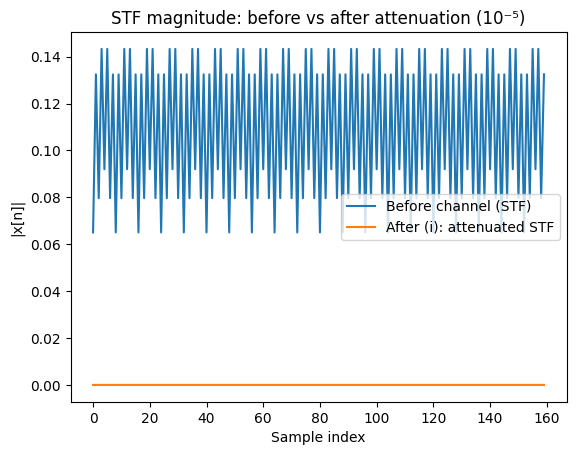

In [ ]:
# Part 2i: Packet transmission and channel distortion

# Adding 100 zero samples before packet for idle period
idle_period = np.zeros(100, dtype=complex)
tx_packet_with_idle = np.concatenate([idle_period, tx_packet])

# Apply channel effect
rx_i = 1e-5 * tx_packet_with_idle

stf_start = 100                     
stf_stop  = stf_start + len(stf_time)
stf_tx    = tx_packet_with_idle[stf_start:stf_stop]
stf_rx_i  = rx_i[stf_start:stf_stop]

plt.figure()
plt.plot(np.abs(stf_tx), label="Before channel (STF)")
plt.plot(np.abs(stf_rx_i), label="After (i): attenuated STF")
plt.title("STF magnitude: before vs after attenuation (10⁻⁵)")
plt.xlabel("Sample index")
plt.ylabel("|x[n]|")
plt.legend()
plt.show()

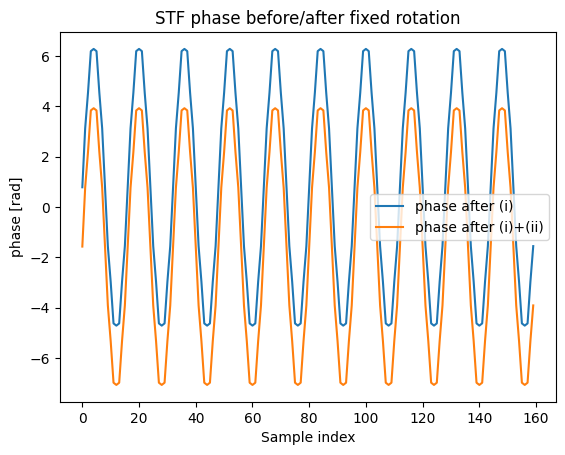

In [274]:
# Part 2ii: Phase shift
rx_ii = rx_i * np.exp(-1j*3*np.pi/4)

stf_rx_i   = rx_i[stf_start:stf_stop]
stf_rx_ii  = rx_ii[stf_start:stf_stop]
phi_i   = np.angle(stf_rx_i)
phi_ii  = np.angle(stf_rx_ii)

plt.figure()
plt.plot(np.unwrap(phi_i),  label="phase after (i)")
plt.plot(np.unwrap(phi_ii), label="phase after (i)+(ii)")
plt.title("STF phase before/after fixed rotation"); plt.xlabel("Sample index"); plt.ylabel("phase [rad]"); plt.legend()
plt.show()

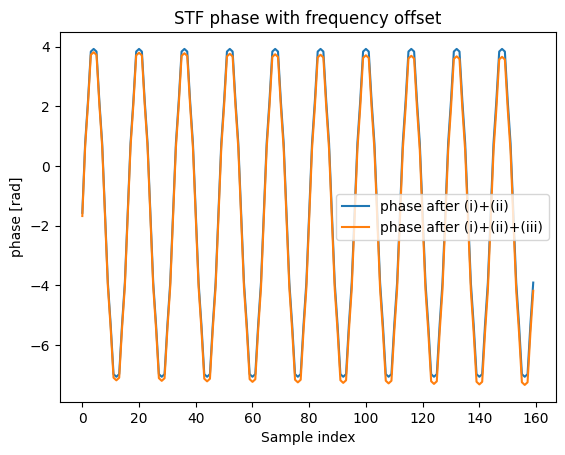

In [275]:
# Part 2iii: Frequency offset between transmitter and receiver... phase drift from transmitters phase

# Suppose the phase drift is exp(-j*2*pi*0.00017) per sample             
k = np.arange(rx_ii.size)          
rx_iii = rx_ii * np.exp(-1j * 2*np.pi * 0.00017  * k)

stf_rx_ii  = rx_ii [stf_start:stf_stop]
stf_rx_iii = rx_iii[stf_start:stf_stop]

phi_ii   = np.unwrap(np.angle(stf_rx_ii))
phi_iii  = np.unwrap(np.angle(stf_rx_iii))

plt.figure()
plt.plot(phi_ii,  label="phase after (i)+(ii)")
plt.plot(phi_iii, label="phase after (i)+(ii)+(iii)")
plt.title("STF phase with frequency offset");
plt.xlabel("Sample index"); plt.ylabel("phase [rad]"); plt.legend()
plt.show()


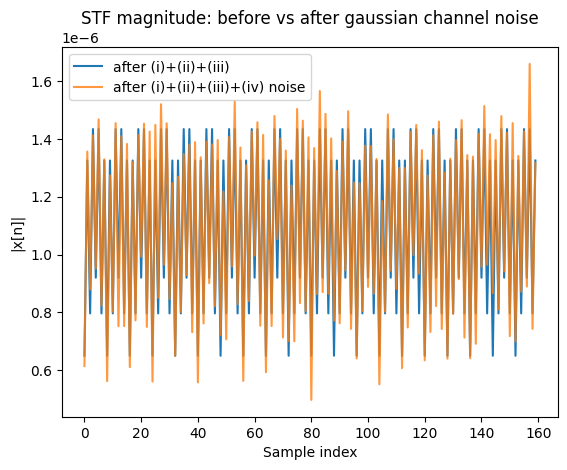

In [276]:
# Part 2iv: Adding Gaussian Noise w mean 0 and variance 10^-14

sigma = np.sqrt(1e-14 / 2.0)          

rng = np.random.default_rng(257) 
noise = rng.normal(0.0, sigma, rx_iii.shape) + 1j * rng.normal(0.0, sigma, rx_iii.shape)

rx_iv = rx_iii + noise

stf_rx_iii = rx_iii[stf_start:stf_stop]          
stf_rx_iv  = rx_iv[stf_start:stf_stop]          

plt.figure()
plt.plot(np.abs(stf_rx_iii), label="after (i)+(ii)+(iii)")
plt.plot(np.abs(stf_rx_iv),  label="after (i)+(ii)+(iii)+(iv) noise", alpha=0.8)
plt.title("STF magnitude: before vs after gaussian channel noise");
plt.xlabel("Sample index"); plt.ylabel("|x[n]|"); plt.legend()
plt.show()

Detected metric indices: [116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133
 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151
 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169
 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187
 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205
 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223
 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241
 242 243 244]
Estimated metric-crossing index: 116


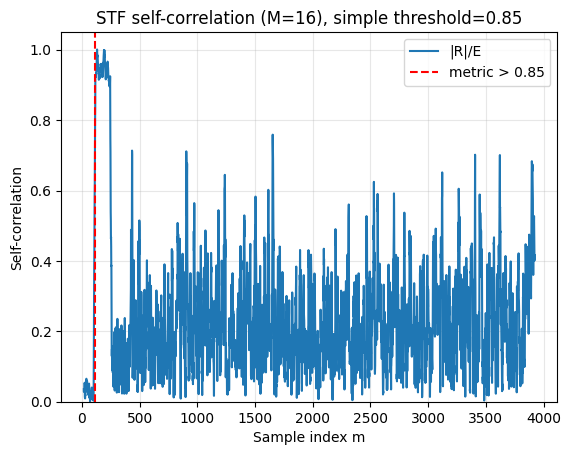

In [277]:
# Part 3: Packet detection, using self-correlation of STF
from numpy.lib.stride_tricks import sliding_window_view

# using the distorted signal
r = rx_iv
M = 16
w = sliding_window_view(r, M)       
R = np.sum(w[M:] * np.conj(w[:-M]), axis=1) # correlation
E = np.sum(np.abs(w[M:])**2, axis=1)      # energy
metric = np.abs(R) / (E + 1e-12)               
m_idx  = np.arange(M, M + metric.size)          

# Simple threshold 
thr = 0.85

det_mask = metric > thr
detected_indices = m_idx[det_mask]
pkt_start_est = int(detected_indices[0]) if detected_indices.size else None

print("Detected metric indices:", detected_indices)
print("Estimated metric-crossing index:", pkt_start_est)

# Plot
plt.figure()
plt.plot(m_idx, metric, label='|R|/E')
if pkt_start_est is not None:
    plt.axvline(pkt_start_est,   color='r', ls='--', label='metric > 0.85')
plt.ylim(0, 1.05)
plt.xlabel('Sample index m'); plt.ylabel('Self-correlation')
plt.title('STF self-correlation (M=16), simple threshold=0.85')
plt.grid(alpha=0.3); plt.legend(); plt.show()


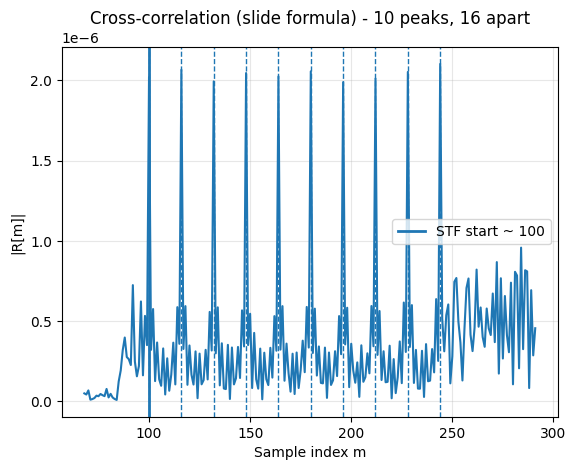

Estimated STF start index: 100
First few peak indices: [100 116 132 148 164]


In [278]:
# Part 4: Packet synchronization... implementing cross-correlation to single out first sample of STF

# reusing the same distorted signal
r = rx_iv                
M = 16                      
s_ref = stf_td[:M]           # 16 sample STF

w = sliding_window_view(r, M)
xc = w @ np.conj(s_ref) # cross-correlation           
xc_mag = np.abs(xc) # magnitude
m_idx = np.arange(xc_mag.size)

# Find first peak after idle period
IDLE_LEN = 100
search_lo = max(0, IDLE_LEN - 32)
search_hi = min(xc_mag.size, IDLE_LEN + 200)
seg = xc_mag[search_lo:search_hi]
thr = 0.7 * seg.max()
rel = np.where(seg >= thr)[0][0]
stf_start_idx = search_lo + rel

# 10 expected peaks (16-sample spacing)
peaks = stf_start_idx + 16*np.arange(10)

# Zoomed plot  
pad = 32
z0 = max(0, stf_start_idx - pad)
z1 = min(xc_mag.size, stf_start_idx + 16*10 + pad)
plt.figure()
plt.plot(m_idx[z0:z1], xc_mag[z0:z1])
for p in peaks[(peaks>=z0)&(peaks<z1)]:
    plt.axvline(p, ls='--', lw=1)
plt.axvline(stf_start_idx, ls='-', lw=2, label=f"STF start ~ {stf_start_idx}")
plt.title("Cross-correlation (slide formula) - 10 peaks, 16 apart")
plt.xlabel("Sample index m"); plt.ylabel("|R[m]|"); plt.grid(True, alpha=0.3); plt.legend()
plt.show()

print("Estimated STF start index:", int(stf_start_idx))
print("First few peak indices:", peaks[:5].astype(int))


In [279]:
# Part 5: Channel estimation and packet decoding

# reminder of constants
N_FFT   = 64
CP_LEN  = 16
STF_LEN = 160        
LTF_CP  = 32
LTF_SYM = 64

r = rx_iv

# 5a, using the LTF to estimate frequency offset between trasmitter and receiver

# From the previous part, we know the exact start of the STF, so we can compute the start of the LTF
# by offsetting by the length of the known STF, and the length of the cyclic prefix of the LTF
ltf1_start = stf_start_idx + STF_LEN + LTF_CP
ltf2_start = ltf1_start + 64

r1 = r[ltf1_start : ltf1_start + LTF_SYM]
r2 = r[ltf2_start : ltf2_start + LTF_SYM]
J   = np.vdot(r1, r2)                              
phi = np.angle(J)
eps = -phi / (2*np.pi*LTF_SYM)

print(f"Channel frequency offset estimate: {eps:.8f}")

# Apply CFO correction to entire received signal
k = np.arange(len(r))
r_corr = r * np.exp(+1j * 2*np.pi * eps * k)


Channel frequency offset estimate: 0.00019746


In [293]:
# Part 5b: using LTF to estimate channel magnitude/phase distortion of each sample

# using the same ltf_pattern as before
sc53 = np.r_[np.arange(-26, 0), [0], np.arange(1, 27)] % N_FFT

S_ref_full = np.zeros(N_FFT, dtype=complex)
S_ref_full[sc53] = ltf_pattern.astype(complex)

R1 = np.fft.fft(r_corr[ltf1_start : ltf1_start + N_FFT], N_FFT)
R2 = np.fft.fft(r_corr[ltf2_start : ltf2_start + N_FFT], N_FFT)
Ravg = 0.5 * (R1 + R2)

H_est = np.zeros(N_FFT, dtype=complex)
mask  = S_ref_full != 0
H_est[mask] = Ravg[mask] / S_ref_full[mask]

# printing out sub carrier estimates
for k in np.r_[np.arange(-26,0), np.arange(1,27)]:
    b = k % N_FFT
    print(f"{k:+3d} {b:2d} {'P' if k in (-21,-7,7,21) else 'D'}  magnitude dist: {abs(H_est[b]):.6g} phase dist: {np.angle(H_est[b]):+.3f}")


-26 38 D  magnitude dist: 1.05083e-05 phase dist: -2.305
-25 39 D  magnitude dist: 1.06171e-05 phase dist: -2.286
-24 40 D  magnitude dist: 1.03117e-05 phase dist: -2.245
-23 41 D  magnitude dist: 9.58155e-06 phase dist: -2.316
-22 42 D  magnitude dist: 9.5242e-06 phase dist: -2.253
-21 43 P  magnitude dist: 1.06907e-05 phase dist: -2.284
-20 44 D  magnitude dist: 9.30256e-06 phase dist: -2.262
-19 45 D  magnitude dist: 1.05415e-05 phase dist: -2.341
-18 46 D  magnitude dist: 1.02248e-05 phase dist: -2.309
-17 47 D  magnitude dist: 9.74937e-06 phase dist: -2.367
-16 48 D  magnitude dist: 1.04299e-05 phase dist: -2.331
-15 49 D  magnitude dist: 9.64041e-06 phase dist: -2.340
-14 50 D  magnitude dist: 9.73451e-06 phase dist: -2.357
-13 51 D  magnitude dist: 9.75778e-06 phase dist: -2.294
-12 52 D  magnitude dist: 1.00907e-05 phase dist: -2.282
-11 53 D  magnitude dist: 1.041e-05 phase dist: -2.306
-10 54 D  magnitude dist: 9.47034e-06 phase dist: -2.343
 -9 55 D  magnitude dist: 1.04636e

In [296]:
# Part 5c: decode using inverse operations of the encoding form the transmitter
data_start  = ltf2_start + N_FFT
sym_len     = N_FFT + CP_LEN
n_samps     = len(r_corr) - data_start
n_syms_rx   = n_samps // sym_len

# Working backwards.. Move to time domain, remove the cyclic prefix, then FFT
rx_td = r_corr[data_start : data_start + n_syms_rx*sym_len].reshape(n_syms_rx, sym_len)
Y     = np.fft.fft(rx_td[:, CP_LEN:], N_FFT, axis=1)

eps   = 1e-12
Z     = Y / (H_est + eps)     

for i in range(n_syms_rx):
    theta = np.angle(np.mean(Z[i, pilot_bins]))
    Z[i] *= np.exp(-1j * theta)

Xhat = Z[:, data_bins]

mapping = {1+0j:(0,0), 0+1j:(0,1), -1+0j:(1,0), 0-1j:(1,1)}
def qpsk_demapper(points: np.ndarray) -> np.ndarray:
    pts = np.asarray(points).ravel()
    out = np.empty((pts.size, 2), dtype=int)
    keys = tuple(mapping.keys())
    for i, z in enumerate(pts):
        k = min(keys, key=lambda c: abs(z - c)**2)
        out[i] = mapping[k]
    return out.reshape(-1)

dec_bits_all = qpsk_demapper(Xhat.reshape(-1))
rx_bits      = dec_bits_all[:PACKET_LENGTH]
tx_bits      = packet[:PACKET_LENGTH]
bit_errors   = int(np.sum(rx_bits != tx_bits))
ber          = bit_errors / PACKET_LENGTH
print(f"Decoded {rx_bits.size} bits. Bit errors: {bit_errors} → BER = {ber:.6e}")
print(f"Original bits sample: {tx_bits[:64]}")
print(f"Decoded bits sample: {rx_bits[:64]}")


Decoded 4160 bits. Bit errors: 0 → BER = 0.000000e+00
Original bits sample: [1 1 1 1 1 0 1 0 0 0 0 1 1 0 1 0 1 1 1 0 1 0 1 0 1 1 1 1 0 1 0 1 1 0 1 0 0
 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 0]
Decoded bits sample: [1 1 1 1 1 0 1 0 0 0 0 1 1 0 1 0 1 1 1 0 1 0 1 0 1 1 1 1 0 1 0 1 1 0 1 0 0
 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 0]
